# Short-Time Fourier Transform (STFT) in Python

This notebook explores the **STFT** from first principles. We will cover:

- Mathematical definition and the need for time-frequency analysis
- Windowing, frames, and the overlap-add concept
- Time-frequency resolution trade-off (Heisenberg uncertainty)
- Spectrogram visualization and dB scaling
- Overlap and hop size effects
- Manual STFT implementation vs `scipy.signal.stft`
- Inverse STFT and perfect reconstruction
- STFT vs standard FFT for non-stationary signals
- Phase and instantaneous frequency estimation
- Zero-padding in the frequency domain

**Requirements:** `numpy`, `matplotlib`, `scipy`


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, istft, get_window
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10


## 1. Mathematical Foundation

The standard Fourier Transform assumes the signal is stationary (frequency content does not change over time). Real-world signals are rarely stationary. The **STFT** solves this by analyzing short, overlapping segments (frames) of the signal.

For a discrete signal $x[n]$, the STFT is:

$$X[m, k] = \sum_{n=0}^{N-1} x[n + mH] \cdot w[n] \cdot e^{-j \frac{2\pi}{N} k n}$$

Where:
- $m$ = frame index (time position)
- $k$ = frequency bin index
- $N$ = window length / FFT size
- $H$ = hop size (step between consecutive frames)
- $w[n]$ = window function (tapers the frame to reduce spectral leakage)

The output is a complex 2D matrix: **frequency vs time**. The magnitude squared of this matrix is called the **spectrogram**.


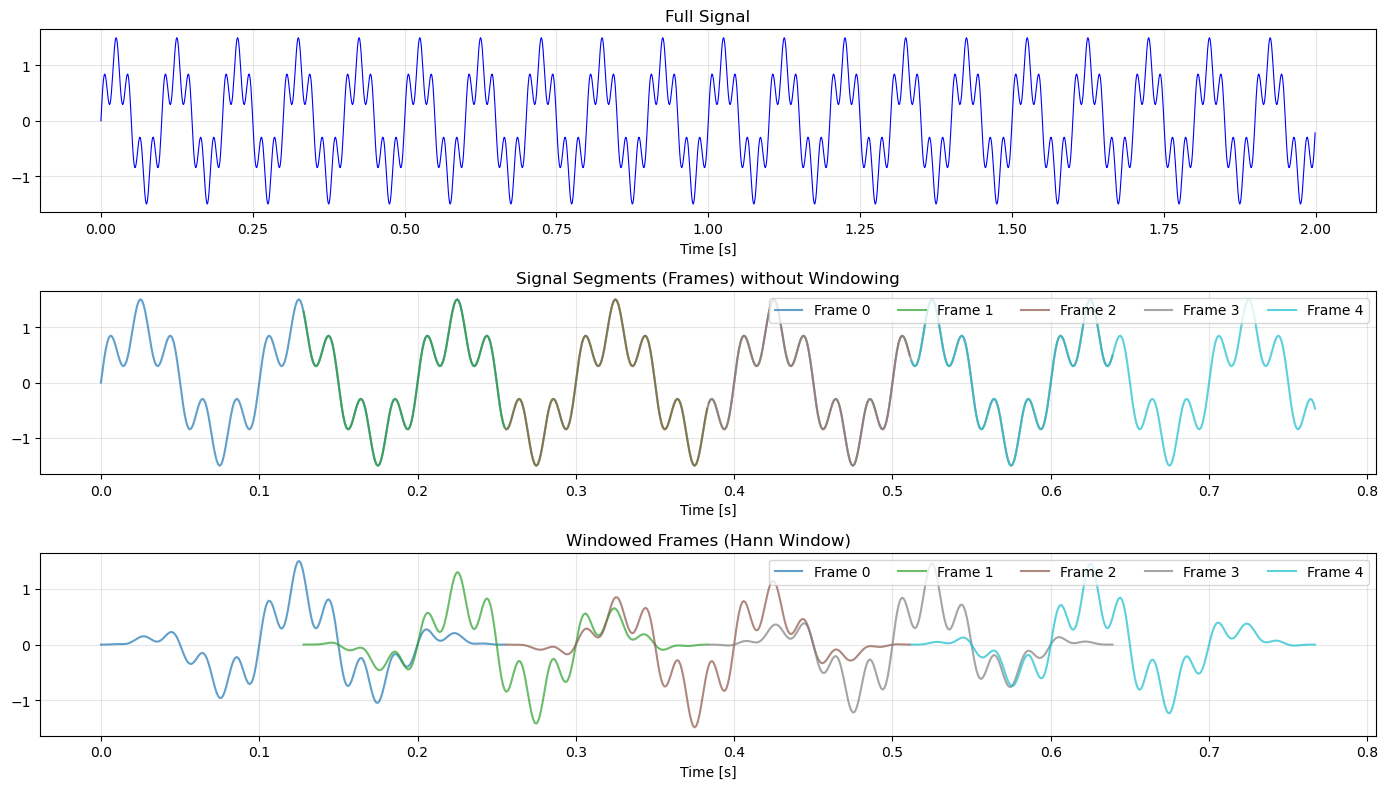

In [2]:
# Parameters
fs = 1000
t = np.linspace(0, 2, 2 * fs, endpoint=False)
signal = np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 50 * t)

# Frame parameters
frame_len = 256
hop_size = 128
num_frames = (len(signal) - frame_len) // hop_size + 1

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Full signal
axes[0].plot(t, signal, 'b-', linewidth=0.8)
axes[0].set_title('Full Signal')
axes[0].set_xlabel('Time [s]')
axes[0].grid(True, alpha=0.3)

# Show first few frames (unwindowed)
colors = plt.cm.tab10(np.linspace(0, 1, 5))
for i in range(5):
    start = i * hop_size
    end = start + frame_len
    t_frame = t[start:end]
    frame = signal[start:end]
    axes[1].plot(t_frame, frame, color=colors[i], alpha=0.7, label=f'Frame {i}')
axes[1].set_title('Signal Segments (Frames) without Windowing')
axes[1].set_xlabel('Time [s]')
axes[1].legend(loc='upper right', ncol=5)
axes[1].grid(True, alpha=0.3)

# Show windowed frames
window = np.hanning(frame_len)
for i in range(5):
    start = i * hop_size
    end = start + frame_len
    t_frame = t[start:end]
    frame = signal[start:end] * window
    axes[2].plot(t_frame, frame, color=colors[i], alpha=0.7, label=f'Frame {i}')
axes[2].set_title('Windowed Frames (Hann Window)')
axes[2].set_xlabel('Time [s]')
axes[2].legend(loc='upper right', ncol=5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Window Functions: Time vs Frequency Domain

The window function is critical. Its frequency response determines:
- **Main lobe width**: frequency resolution (ability to separate nearby tones)
- **Side lobe level**: spectral leakage (energy bleeding into other bins)

| Window | Main Lobe | First Side Lobe | Best For |
|--------|-----------|-----------------|----------|
| Rectangular | Narrowest | -13 dB | Transient analysis |
| Hann | Moderate | -31 dB | General purpose |
| Hamming | Moderate | -42 dB | Reduced leakage |
| Blackman | Wide | -57 dB | Low leakage, low resolution |

A wider main lobe smears nearby frequencies together. Higher side lobes create artifacts from strong frequency components.


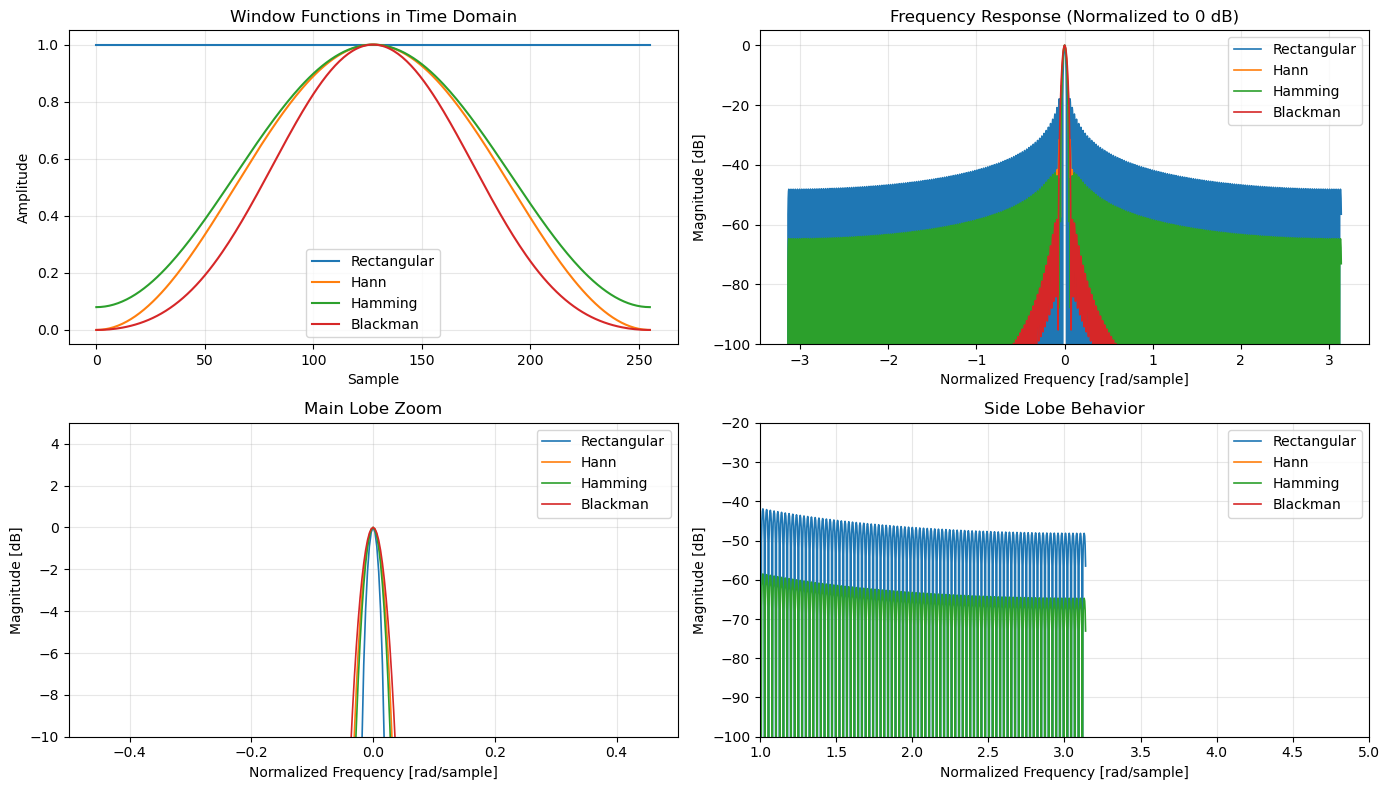

In [3]:
N_win = 256
windows = {
    'Rectangular': np.ones(N_win),
    'Hann': np.hanning(N_win),
    'Hamming': np.hamming(N_win),
    'Blackman': np.blackman(N_win)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Time domain
ax_time = axes[0, 0]
for name, w in windows.items():
    ax_time.plot(w, label=name, linewidth=1.5)
ax_time.set_title('Window Functions in Time Domain')
ax_time.set_xlabel('Sample')
ax_time.set_ylabel('Amplitude')
ax_time.legend()
ax_time.grid(True, alpha=0.3)

# Frequency response (magnitude dB)
ax_freq = axes[0, 1]
for name, w in windows.items():
    W = np.fft.fftshift(np.fft.fft(w, 2048))
    freq = np.fft.fftshift(np.fft.fftfreq(2048))
    mag_db = 20 * np.log10(np.abs(W) + 1e-12)
    mag_db -= np.max(mag_db)
    ax_freq.plot(freq * 2 * np.pi, mag_db, label=name, linewidth=1.2)
ax_freq.set_title('Frequency Response (Normalized to 0 dB)')
ax_freq.set_xlabel('Normalized Frequency [rad/sample]')
ax_freq.set_ylabel('Magnitude [dB]')
ax_freq.set_ylim(-100, 5)
ax_freq.legend()
ax_freq.grid(True, alpha=0.3)

# Zoomed main lobe
ax_zoom = axes[1, 0]
for name, w in windows.items():
    W = np.fft.fftshift(np.fft.fft(w, 2048))
    freq = np.fft.fftshift(np.fft.fftfreq(2048))
    mag_db = 20 * np.log10(np.abs(W) + 1e-12)
    mag_db -= np.max(mag_db)
    ax_zoom.plot(freq * 2 * np.pi, mag_db, label=name, linewidth=1.2)
ax_zoom.set_title('Main Lobe Zoom')
ax_zoom.set_xlabel('Normalized Frequency [rad/sample]')
ax_zoom.set_ylabel('Magnitude [dB]')
ax_zoom.set_xlim(-0.5, 0.5)
ax_zoom.set_ylim(-10, 5)
ax_zoom.legend()
ax_zoom.grid(True, alpha=0.3)

# Side lobe zoom
ax_side = axes[1, 1]
for name, w in windows.items():
    W = np.fft.fftshift(np.fft.fft(w, 2048))
    freq = np.fft.fftshift(np.fft.fftfreq(2048))
    mag_db = 20 * np.log10(np.abs(W) + 1e-12)
    mag_db -= np.max(mag_db)
    ax_side.plot(freq * 2 * np.pi, mag_db, label=name, linewidth=1.2)
ax_side.set_title('Side Lobe Behavior')
ax_side.set_xlabel('Normalized Frequency [rad/sample]')
ax_side.set_ylabel('Magnitude [dB]')
ax_side.set_xlim(1, 5)
ax_side.set_ylim(-100, -20)
ax_side.legend()
ax_side.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Computing the STFT

We can implement the STFT manually to understand the mechanics, then compare with `scipy.signal.stft`.

Key parameters:
- **nperseg**: window length (frame size in samples)
- **noverlap**: overlap between frames (typically 50-75% of nperseg)
- **nfft**: FFT size (zero-padding for finer frequency grid)
- **fs**: sampling frequency

The hop size is $H = \text{nperseg} - \text{noverlap}$.


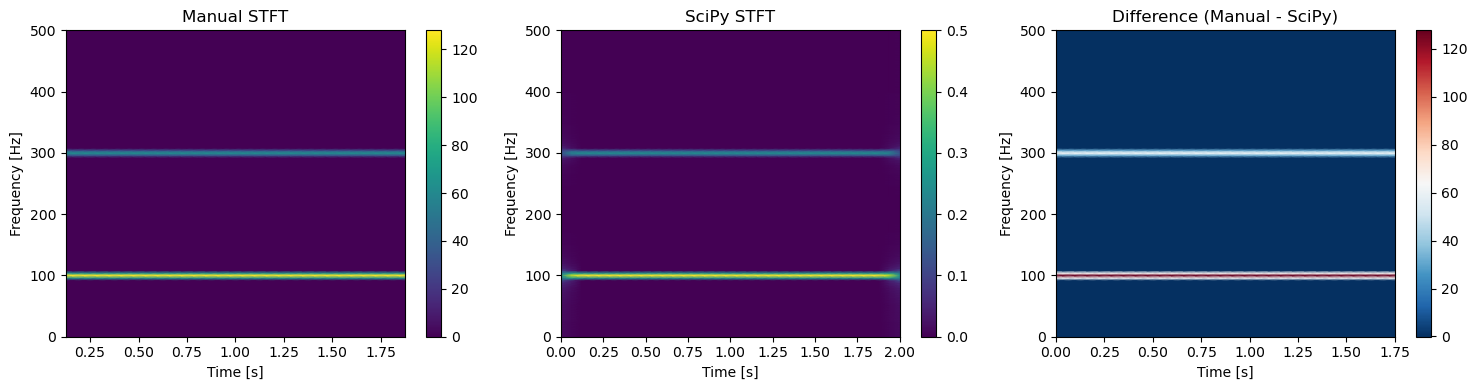

Shapes: Manual (257, 29), SciPy (257, 33)
Max magnitude difference: 1.28e+02


In [12]:
def stft_manual(x, fs, window, nperseg, noverlap, nfft=None):
    """Manual STFT using frame-by-frame DFT."""
    if nfft is None:
        nfft = nperseg
    hop = nperseg - noverlap
    n_frames = (len(x) - noverlap) // hop
    
    stft_matrix = np.zeros((nfft // 2 + 1, n_frames), dtype=complex)
    times = np.zeros(n_frames)
    
    win = get_window(window, nperseg) if isinstance(window, str) else window
    
    for i in range(n_frames):
        start = i * hop
        end = start + nperseg
        frame = x[start:end]
        
        if len(frame) < nperseg:
            frame = np.pad(frame, (0, nperseg - len(frame)))
        
        windowed = frame * win
        
        if nfft > nperseg:
            windowed = np.pad(windowed, (0, nfft - nperseg))
        
        spectrum = np.fft.rfft(windowed, n=nfft)
        stft_matrix[:, i] = spectrum
        times[i] = (start + nperseg // 2) / fs
    
    freqs = np.fft.rfftfreq(nfft, 1/fs)
    return freqs, times, stft_matrix


# Test signal
fs = 2048
t = np.linspace(0, 2, 2 * fs, endpoint=False)
x = np.sin(2 * np.pi * 100 * t) + 0.5 * np.sin(2 * np.pi * 300 * t)

# Manual STFT
freqs_m, times_m, Zxx_m = stft_manual(x, fs, 'hann', nperseg=512, noverlap=384, nfft=512)

# SciPy STFT
freqs_s, times_s, Zxx_s = stft(x, fs=fs, window='hann', nperseg=512, noverlap=384, nfft=512)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].pcolormesh(times_m, freqs_m, np.abs(Zxx_m), shading='gouraud', cmap='viridis')
axes[0].set_title('Manual STFT')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_ylim(0, 500)
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(times_s, freqs_s, np.abs(Zxx_s), shading='gouraud', cmap='viridis')
axes[1].set_title('SciPy STFT')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(0, 500)
fig.colorbar(im2, ax=axes[1])

# FIX: trim to common frame count before subtracting
min_frames = min(Zxx_m.shape[1], Zxx_s.shape[1])
diff = np.abs(Zxx_m[:, :min_frames]) - np.abs(Zxx_s[:, :min_frames])
im3 = axes[2].pcolormesh(times_s[:min_frames], freqs_s, diff, shading='gouraud', cmap='RdBu_r')
axes[2].set_title('Difference (Manual - SciPy)')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Frequency [Hz]')
axes[2].set_ylim(0, 500)
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

print("Shapes: Manual {}, SciPy {}".format(Zxx_m.shape, Zxx_s.shape))
print("Max magnitude difference: {:.2e}".format(np.max(np.abs(diff))))


## 4. Time-Frequency Resolution Trade-off

The STFT cannot simultaneously achieve arbitrarily fine time and frequency resolution. This is the **Heisenberg-Gabor uncertainty principle** in signal processing:

$$\Delta t \cdot \Delta f \geq \frac{1}{4\pi}$$

- **Short window**: excellent time resolution, poor frequency resolution
- **Long window**: excellent frequency resolution, poor time resolution

The product is bounded by a constant. For a Gaussian window, the equality holds (optimal joint resolution).


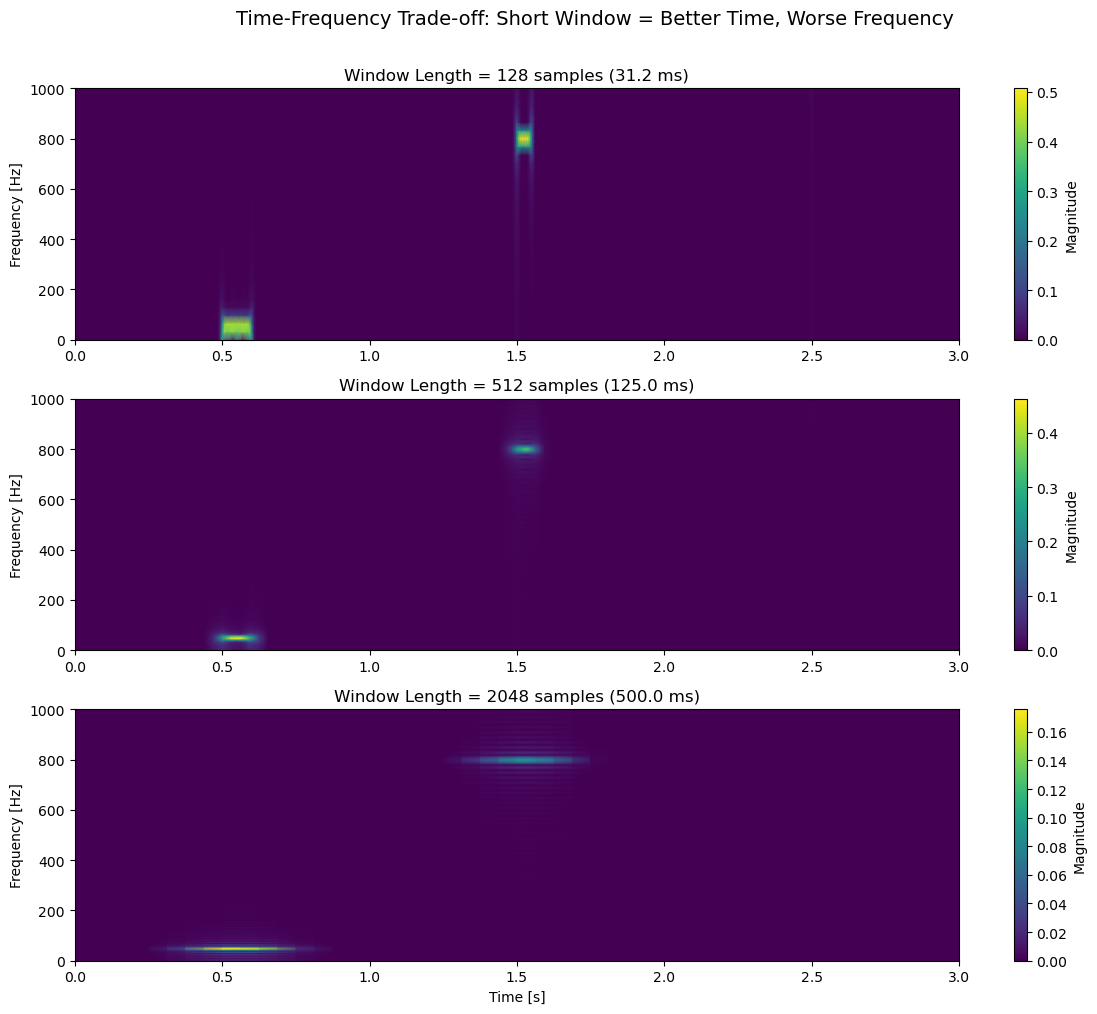

In [5]:
fs = 4096
t = np.linspace(0, 3, 3 * fs, endpoint=False)

# Non-stationary signal with distinct time-frequency events
signal = np.zeros_like(t)
# Low freq burst at 0.5s
idx1 = slice(int(0.5*fs), int(0.6*fs))
signal[idx1] = np.sin(2 * np.pi * 50 * t[idx1])
# High freq burst at 1.5s
idx2 = slice(int(1.5*fs), int(1.55*fs))
signal[idx2] = np.sin(2 * np.pi * 800 * t[idx2])
# Chirp from 2.0s to 2.5s
idx3 = slice(int(2.0*fs), int(2.5*fs))
t_ch = t[idx3]
signal[idx3] = np.sin(2 * np.pi * (200 + 400*(t_ch - t_ch[0])/(t_ch[-1]-t_ch[0])) * t_ch)

window_lengths = [128, 512, 2048]
hop_ratio = 0.75

fig, axes = plt.subplots(len(window_lengths), 1, figsize=(12, 10))

for idx, nperseg in enumerate(window_lengths):
    noverlap = int(nperseg * hop_ratio)
    f, t_stft, Zxx = stft(signal, fs=fs, window='hann', nperseg=nperseg, 
                          noverlap=noverlap, nfft=nperseg)
    
    im = axes[idx].pcolormesh(t_stft, f, np.abs(Zxx), shading='gouraud', cmap='viridis')
    duration_ms = nperseg / fs * 1000
    axes[idx].set_title('Window Length = {} samples ({:.1f} ms)'.format(nperseg, duration_ms))
    axes[idx].set_ylabel('Frequency [Hz]')
    axes[idx].set_ylim(0, 1000)
    fig.colorbar(im, ax=axes[idx], label='Magnitude')

axes[-1].set_xlabel('Time [s]')
plt.suptitle('Time-Frequency Trade-off: Short Window = Better Time, Worse Frequency', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 5. Overlap and Hop Size

Overlap between consecutive frames is essential for smooth spectrograms and perfect reconstruction. The hop size is:

$$H = N - \text{noverlap}$$

Common configurations:
- **0% overlap**: blocky, no redundancy, fast
- **50% overlap**: standard for Hann windows (COLA property)
- **75% overlap**: very smooth, higher computational cost

For a Hann window at 50% overlap, the sum of shifted windows is constant. This is the **Constant Overlap-Add (COLA)** condition, required for perfect inverse STFT reconstruction.


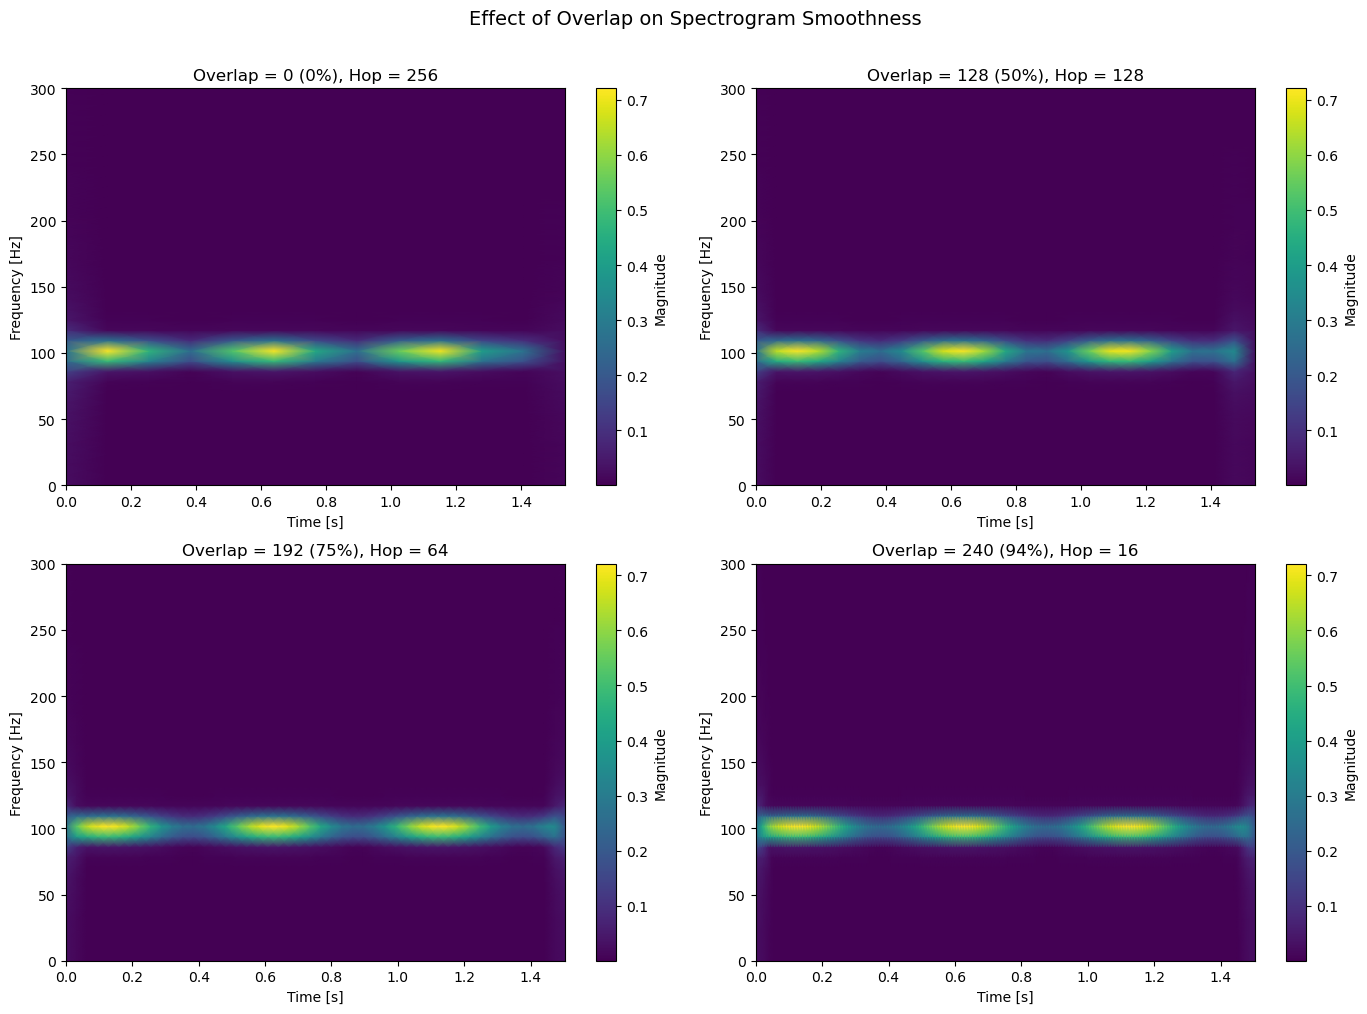

In [6]:
fs = 2000
t = np.linspace(0, 1.5, int(1.5 * fs), endpoint=False)
x = np.sin(2 * np.pi * 100 * t) * (1 + 0.5 * np.sin(2 * np.pi * 2 * t))  # AM signal

nperseg = 256
overlaps = [0, 128, 192, 240]  # 0%, 50%, 75%, ~94%

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, ov in enumerate(overlaps):
    ax = axes[idx // 2, idx % 2]
    f, t_stft, Zxx = stft(x, fs=fs, window='hann', nperseg=nperseg, 
                          noverlap=ov, nfft=nperseg)
    im = ax.pcolormesh(t_stft, f, np.abs(Zxx), shading='gouraud', cmap='viridis')
    hop = nperseg - ov
    pct = ov / nperseg * 100
    ax.set_title('Overlap = {} ({:.0f}%), Hop = {}'.format(ov, pct, hop))
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Frequency [Hz]')
    ax.set_ylim(0, 300)
    fig.colorbar(im, ax=ax, label='Magnitude')

plt.suptitle('Effect of Overlap on Spectrogram Smoothness', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 6. Inverse STFT and Perfect Reconstruction

The Inverse STFT (ISTFT) reconstructs the time-domain signal using the **overlap-add** method. With a COLA-compliant window and sufficient overlap, reconstruction is perfect up to numerical precision.

The process:
1. Compute inverse FFT of each STFT column
2. Apply the synthesis window
3. Overlap-add the time-domain frames
4. Normalize by the sum of overlapping windows

SciPy's `istft` handles this automatically.


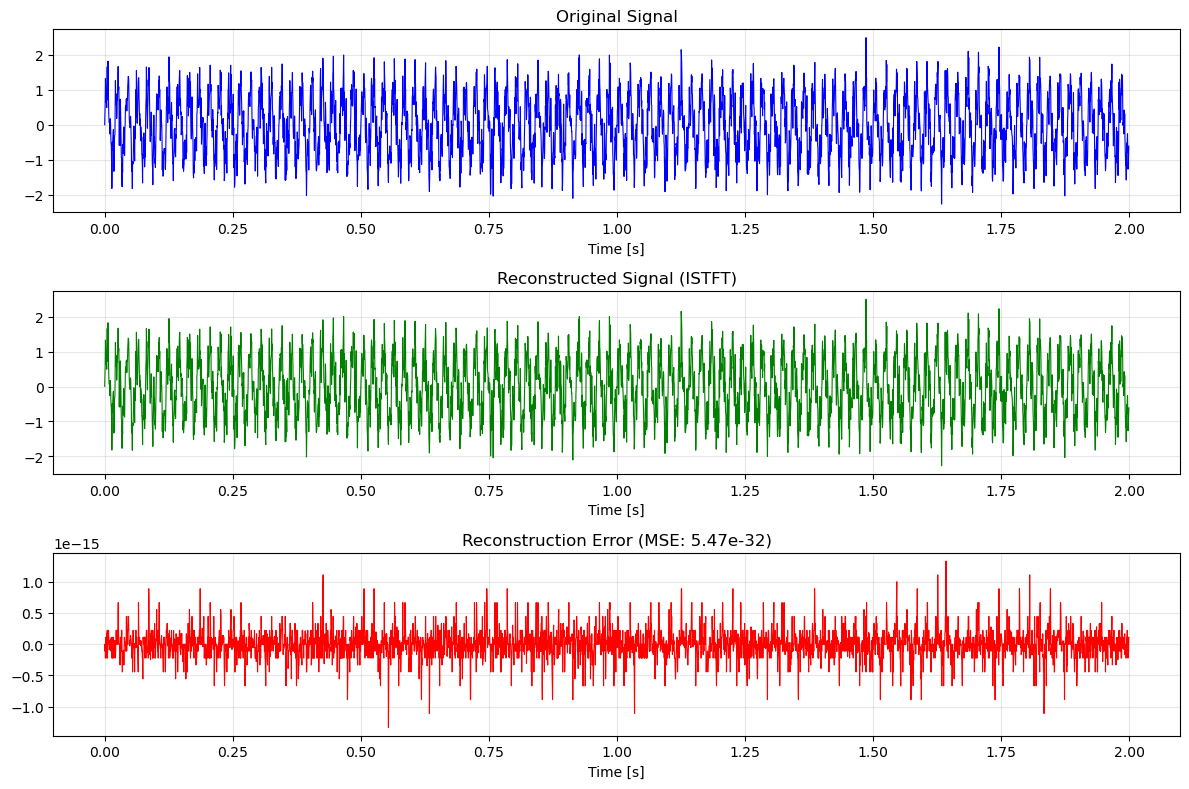

Original length: 4000
Reconstructed length: 4000
Max reconstruction error: 1.33e-15


In [7]:
fs = 2000
t = np.linspace(0, 2, 2 * fs, endpoint=False)
x_orig = (np.sin(2 * np.pi * 50 * t) + 
          0.5 * np.sin(2 * np.pi * 200 * t) + 
          0.3 * np.random.randn(len(t)))

# Forward STFT
nperseg = 512
noverlap = 384  # 75% overlap
nfft = 512

f, t_stft, Zxx = stft(x_orig, fs=fs, window='hann', nperseg=nperseg,
                      noverlap=noverlap, nfft=nfft)

# Inverse STFT
t_rec, x_rec = istft(Zxx, fs=fs, window='hann', nperseg=nperseg,
                     noverlap=noverlap, nfft=nfft)

x_rec = x_rec[:len(x_orig)]

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(t, x_orig, 'b-', linewidth=0.8)
axes[0].set_title('Original Signal')
axes[0].set_xlabel('Time [s]')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_rec[:len(x_rec)], x_rec, 'g-', linewidth=0.8)
axes[1].set_title('Reconstructed Signal (ISTFT)')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True, alpha=0.3)

error = x_orig - x_rec
axes[2].plot(t, error, 'r-', linewidth=0.8)
mse = np.mean(error**2)
axes[2].set_title('Reconstruction Error (MSE: {:.2e})'.format(mse))
axes[2].set_xlabel('Time [s]')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Original length:", len(x_orig))
print("Reconstructed length:", len(x_rec))
print("Max reconstruction error: {:.2e}".format(np.max(np.abs(error))))


## 7. STFT vs Standard FFT for Non-Stationary Signals

The standard FFT averages frequency content across the entire signal, completely losing time information. The STFT preserves time localization, making it essential for signals whose spectra evolve.

Here we compare the global FFT spectrum against the STFT spectrogram for a signal with three distinct time-frequency events.


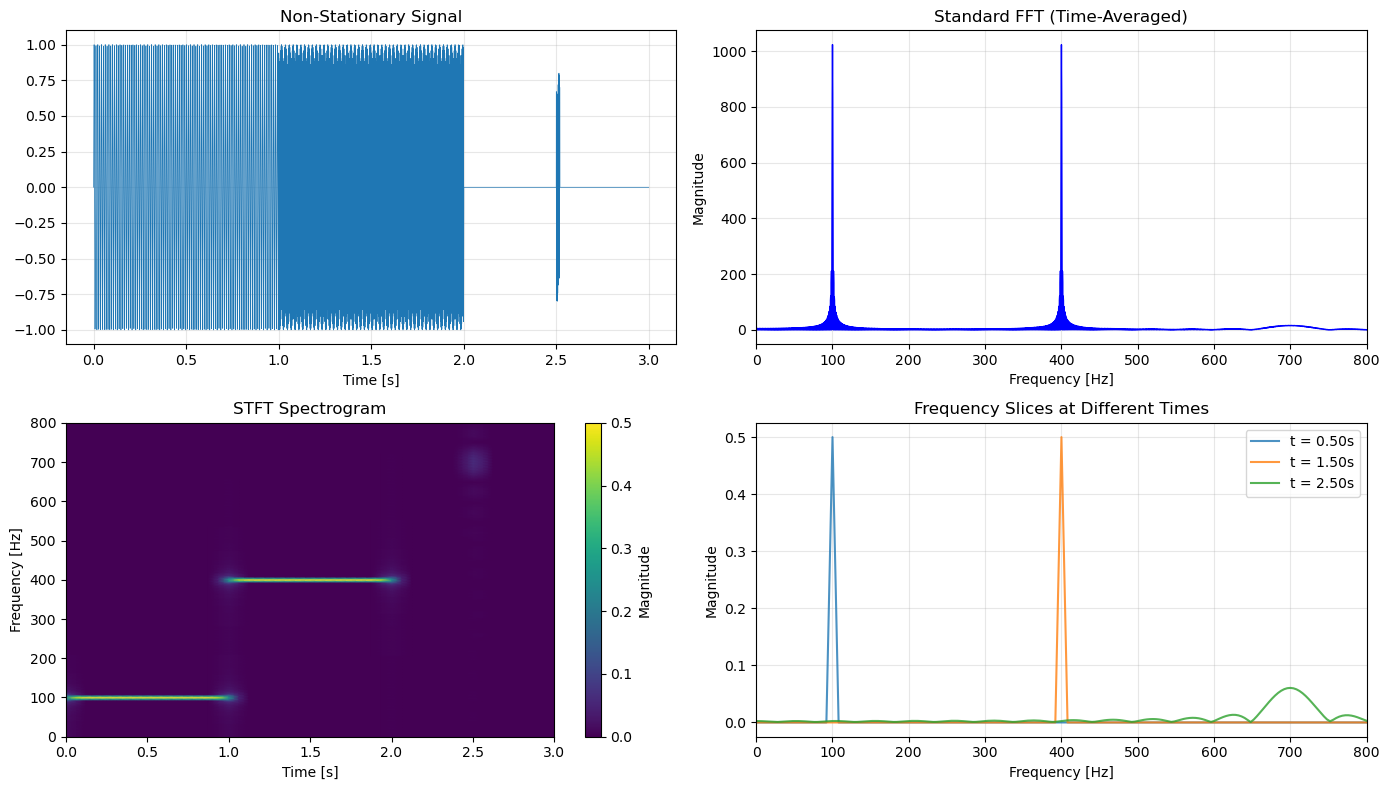

In [13]:
fs = 2048
t = np.linspace(0, 3, 3 * fs, endpoint=False)

# Signal with three distinct time-frequency events
sig = np.zeros_like(t)
sig[:fs] += np.sin(2 * np.pi * 100 * t[:fs])
sig[fs:2*fs] += np.sin(2 * np.pi * 400 * t[fs:2*fs])
click = slice(int(2.5*fs), int(2.52*fs))
sig[click] += 0.8 * np.sin(2 * np.pi * 700 * t[click])

# Standard FFT
X_fft = np.fft.rfft(sig)
f_fft = np.fft.rfftfreq(len(sig), 1/fs)

# STFT
f_stft, t_stft, Zxx = stft(sig, fs=fs, window='hann', nperseg=512, noverlap=384)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(t, sig, linewidth=0.5)
axes[0, 0].set_title('Non-Stationary Signal')
axes[0, 0].set_xlabel('Time [s]')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(f_fft, np.abs(X_fft), 'b-', linewidth=1)
axes[0, 1].set_title('Standard FFT (Time-Averaged)')
axes[0, 1].set_xlabel('Frequency [Hz]')
axes[0, 1].set_ylabel('Magnitude')
axes[0, 1].set_xlim(0, 800)
axes[0, 1].grid(True, alpha=0.3)

im = axes[1, 0].pcolormesh(t_stft, f_stft, np.abs(Zxx), shading='gouraud', cmap='viridis')
axes[1, 0].set_title('STFT Spectrogram')
axes[1, 0].set_xlabel('Time [s]')
axes[1, 0].set_ylabel('Frequency [Hz]')
axes[1, 0].set_ylim(0, 800)
fig.colorbar(im, ax=axes[1, 0], label='Magnitude')

# FIX: find frame indices closest to desired times instead of hardcoding
idx_05 = np.argmin(np.abs(t_stft - 0.5))
idx_15 = np.argmin(np.abs(t_stft - 1.5))
idx_25 = np.argmin(np.abs(t_stft - 2.5))

axes[1, 1].plot(f_stft, np.abs(Zxx[:, idx_05]), label='t = {:.2f}s'.format(t_stft[idx_05]), alpha=0.8)
axes[1, 1].plot(f_stft, np.abs(Zxx[:, idx_15]), label='t = {:.2f}s'.format(t_stft[idx_15]), alpha=0.8)
axes[1, 1].plot(f_stft, np.abs(Zxx[:, idx_25]), label='t = {:.2f}s'.format(t_stft[idx_25]), alpha=0.8)
axes[1, 1].set_title('Frequency Slices at Different Times')
axes[1, 1].set_xlabel('Frequency [Hz]')
axes[1, 1].set_ylabel('Magnitude')
axes[1, 1].set_xlim(0, 800)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Phase and Instantaneous Frequency

The STFT returns complex values. While the magnitude yields the spectrogram, the **phase** encodes precise timing information. The instantaneous frequency at a time-frequency point can be estimated from the phase derivative across time:

$$f_i(t, \omega) \approx \frac{1}{2\pi} \frac{\Delta \phi}{\Delta t}$$

This principle underlies the **phase vocoder**, used for time-stretching and pitch-shifting. Phase must be unwrapped along the time axis before differentiation.


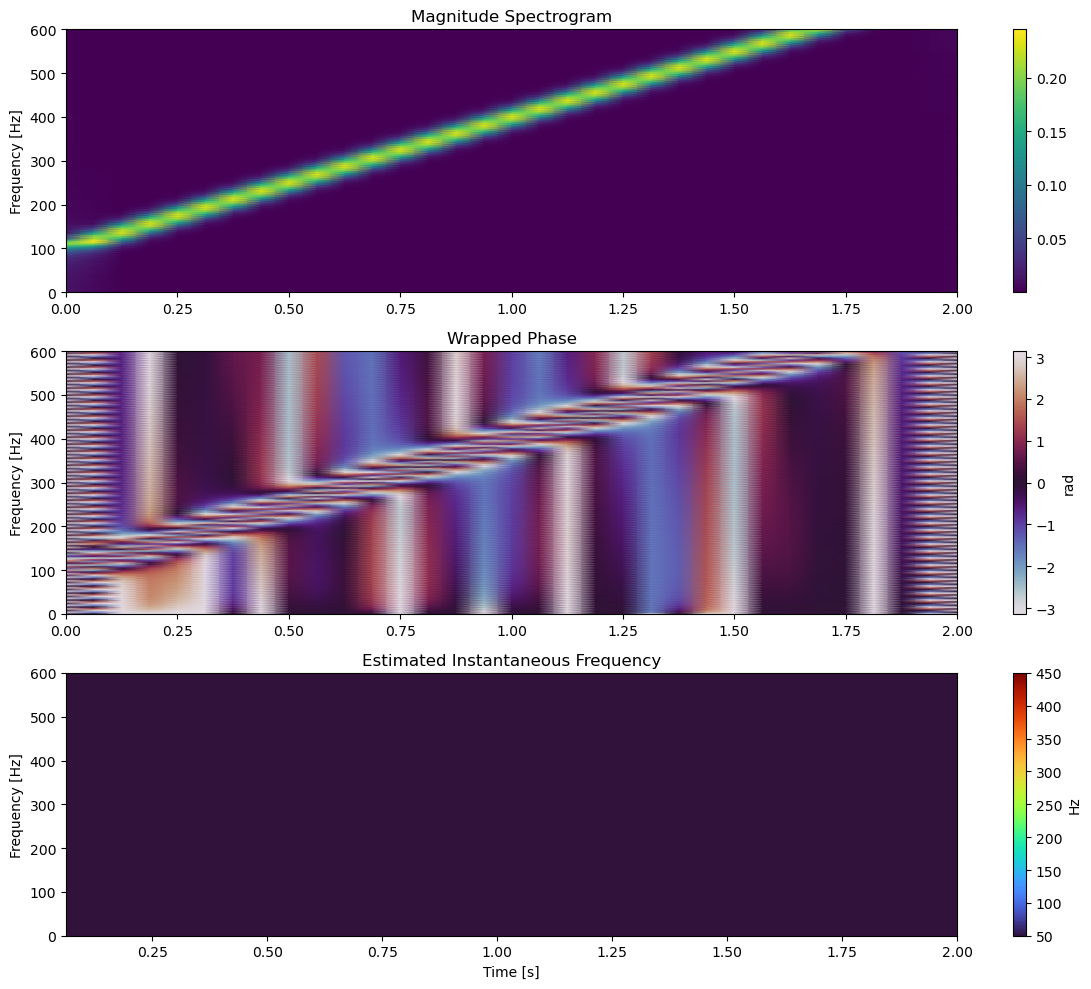

In [9]:
fs = 2048
t = np.linspace(0, 2, 2 * fs, endpoint=False)
# Linear chirp: frequency increases from 100 to 400 Hz
chirp = np.sin(2 * np.pi * (100 + 150 * t) * t)

nperseg = 512
noverlap = 384
f, t_stft, Zxx = stft(chirp, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)

# Phase and unwrap along time (axis=1)
phase = np.angle(Zxx)
phase_unwrapped = np.unwrap(phase, axis=1)

# Instantaneous frequency estimate
dt = (nperseg - noverlap) / fs
inst_freq = np.diff(phase_unwrapped, axis=1) / (2 * np.pi * dt)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

im1 = axes[0].pcolormesh(t_stft, f, np.abs(Zxx), shading='gouraud', cmap='viridis')
axes[0].set_title('Magnitude Spectrogram')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_ylim(0, 600)
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(t_stft, f, phase, shading='gouraud', cmap='twilight')
axes[1].set_title('Wrapped Phase')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(0, 600)
fig.colorbar(im2, ax=axes[1], label='rad')

im3 = axes[2].pcolormesh(t_stft[1:], f, inst_freq, shading='gouraud', cmap='turbo',
                          vmin=50, vmax=450)
axes[2].set_title('Estimated Instantaneous Frequency')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Frequency [Hz]')
axes[2].set_ylim(0, 600)
fig.colorbar(im3, ax=axes[2], label='Hz')

plt.tight_layout()
plt.show()


## 9. Zero-Padding in STFT

Zero-padding the windowed frame before the FFT increases the number of frequency samples (interpolates the spectrum) but does **not** improve true frequency resolution. True resolution depends only on the physical window duration.

Zero-padding is useful for:
- Smoother visual appearance in spectrograms
- Aligning frequency bins to specific values
- Finer frequency sampling for peak detection algorithms

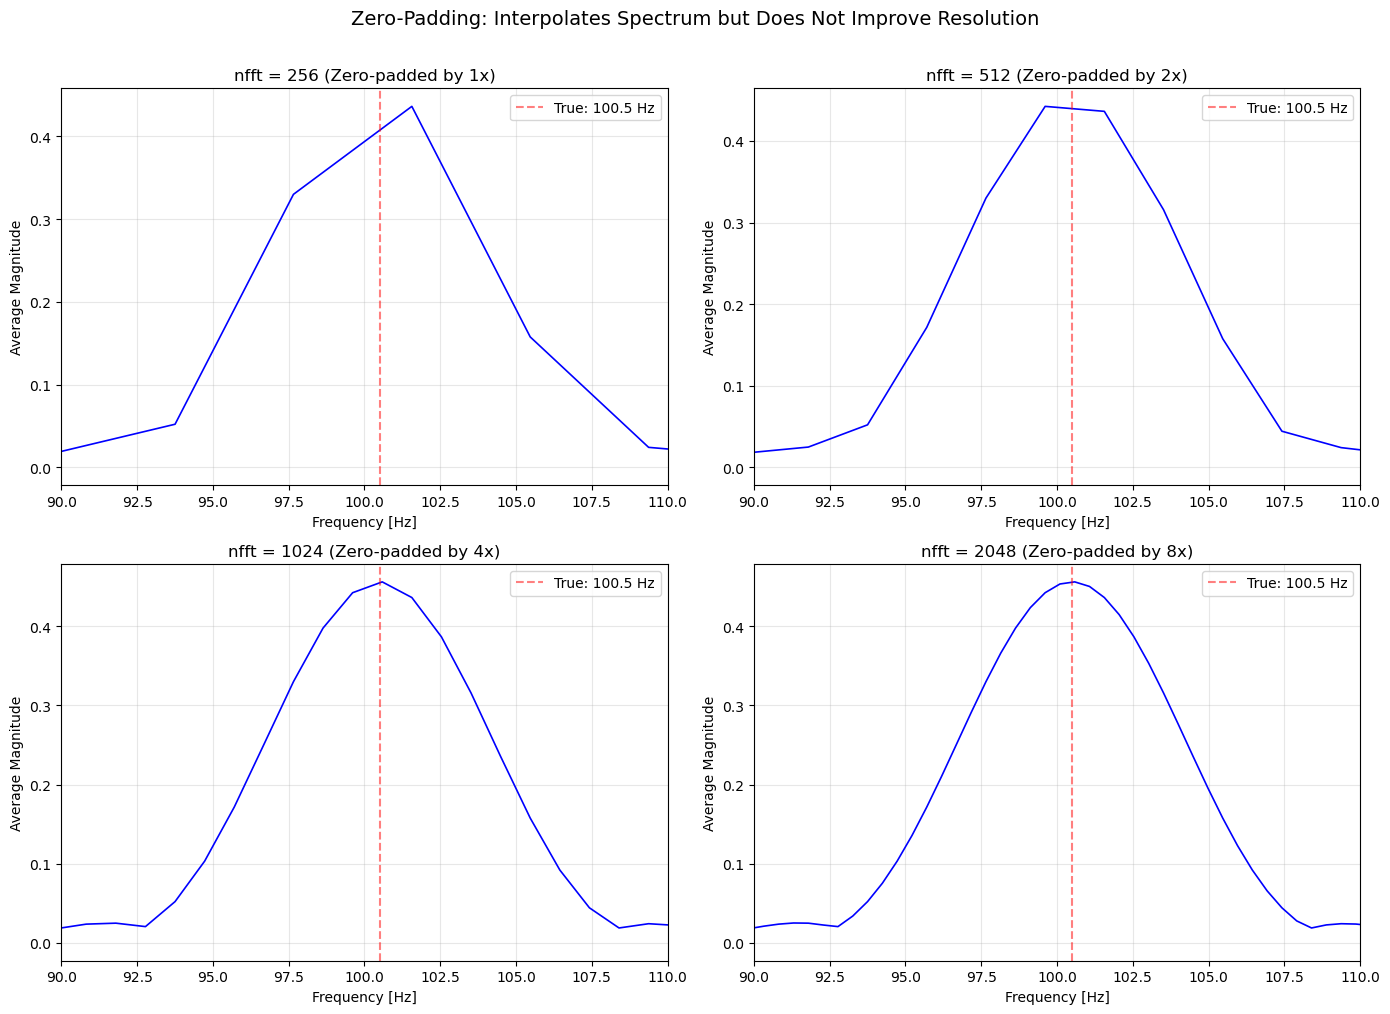

In [10]:
fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)
x = np.sin(2 * np.pi * 100.5 * t)  # Non-integer number of cycles

nperseg = 256
noverlap = 192
nffts = [256, 512, 1024, 2048]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, nfft in enumerate(nffts):
    ax = axes[idx // 2, idx % 2]
    f, t_stft, Zxx = stft(x, fs=fs, window='hann', nperseg=nperseg,
                          noverlap=noverlap, nfft=nfft)
    
    avg_spec = np.mean(np.abs(Zxx), axis=1)
    ax.plot(f, avg_spec, 'b-', linewidth=1.2)
    ax.axvline(100.5, color='r', linestyle='--', alpha=0.5, label='True: 100.5 Hz')
    ratio = nfft // nperseg
    ax.set_title('nfft = {} (Zero-padded by {}x)'.format(nfft, ratio))
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Average Magnitude')
    ax.set_xlim(90, 110)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Zero-Padding: Interpolates Spectrum but Does Not Improve Resolution', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 10. dB Scaling and Dynamic Range

Spectrograms are often displayed on a logarithmic (dB) scale to reveal low-amplitude features hidden in linear plots. The conversion is:

$$X_{dB}[m, k] = 20 \log_{10}(|X[m, k]|)$$

We typically normalize to the maximum value and clip to a useful dynamic range (e.g., -100 dB to 0 dB). This reveals weak spectral components that would otherwise be invisible.


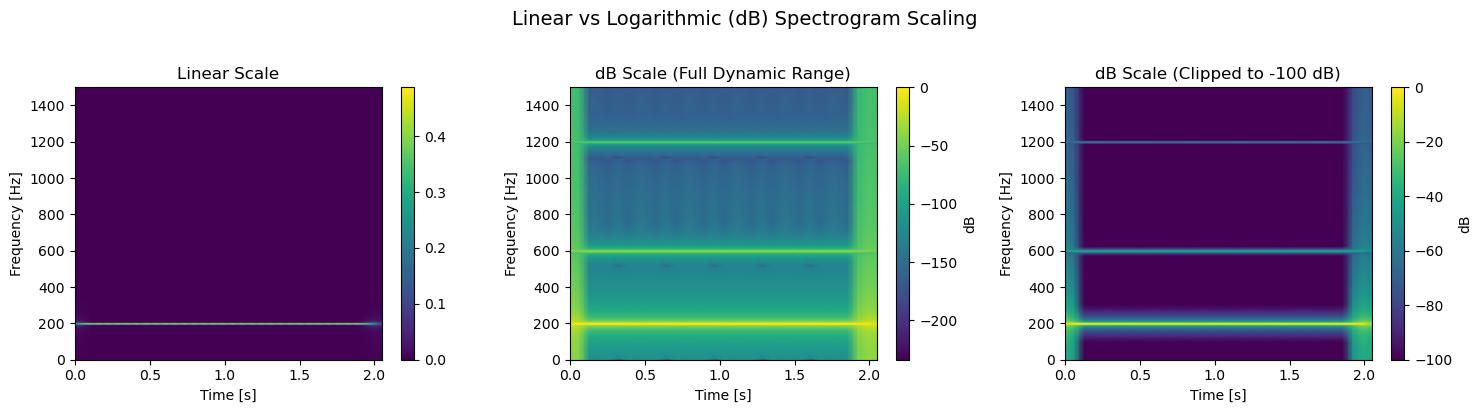

In [11]:
fs = 4000
t = np.linspace(0, 2, 2 * fs, endpoint=False)
# Signal with strong and weak components
sig_db = (np.sin(2 * np.pi * 200 * t) + 
          0.01 * np.sin(2 * np.pi * 600 * t) + 
          0.001 * np.sin(2 * np.pi * 1200 * t))

f, t_stft, Zxx = stft(sig_db, fs=fs, window='hann', nperseg=1024, noverlap=768)

mag = np.abs(Zxx)
mag_db = 20 * np.log10(mag + 1e-12)
mag_db_norm = mag_db - np.max(mag_db)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].pcolormesh(t_stft, f, mag, shading='gouraud', cmap='viridis')
axes[0].set_title('Linear Scale')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_ylim(0, 1500)
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(t_stft, f, mag_db_norm, shading='gouraud', cmap='viridis')
axes[1].set_title('dB Scale (Full Dynamic Range)')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(0, 1500)
fig.colorbar(im2, ax=axes[1], label='dB')

im3 = axes[2].pcolormesh(t_stft, f, mag_db_norm, shading='gouraud', 
                          cmap='viridis', vmin=-100, vmax=0)
axes[2].set_title('dB Scale (Clipped to -100 dB)')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Frequency [Hz]')
axes[2].set_ylim(0, 1500)
fig.colorbar(im3, ax=axes[2], label='dB')

plt.suptitle('Linear vs Logarithmic (dB) Spectrogram Scaling', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Summary

| Parameter | Effect | Trade-off |
|-----------|--------|-----------|
| **Window length** | Determines frequency resolution | Long = better freq, worse time |
| **Overlap** | Smoothness in time axis | Higher = smoother, more computation |
| **Window type** | Leakage vs main lobe width | Low leakage = wider main lobe |
| **Zero-padding** | Frequency bin interpolation | Smoother look, no real resolution gain |
| **dB scale** | Reveals weak components | Compresses dynamic range |

Key takeaways:
- The STFT is the standard tool for analyzing non-stationary signals
- You cannot escape the time-frequency uncertainty principle; choose your window to match the features you need to resolve
- Always use overlap (50-75%) for smooth, artifact-free spectrograms
- The Hann window with 50% overlap satisfies the COLA condition, enabling perfect reconstruction via ISTFT
- Use dB scaling to visualize weak spectral components alongside strong ones